<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_11_Long_Short_Term_Memory_(LSTM)0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uploading and Extracting the Dataset
from google.colab import files
uploaded = files.upload()

Saving sensor_reading.npz to sensor_reading.npz


In [ ]:
# Loading the Dataset
# loading the .npz file and checking its contents
import numpy as np

# Load dataset
data = np.load('sensor_reading.npz')

# Viewing keys inside the file
print("Keys inside dataset:", data.files)

# Extracting the data
X = data['X']
y = data['y']

# Displaying the shape
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Keys inside dataset: ['X', 'y']
Shape of X: (500, 1)
Shape of y: (500,)


In [ ]:
# Split Data into Training and Testing Sets
# Using 80% training and 20% testing.
# Splitting ratio
split_ratio = 0.8

split_index = int(len(X) * split_ratio)

# Training data
X_train = X[:split_index]
y_train = y[:split_index]

# Testing data
X_test = X[split_index:]
y_test = y[split_index:]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [ ]:
# Reshaping Data for LSTM
# LSTM requires 3D input: (samples, timesteps, features).

# Since each sample has one value. We reshape to samples, 1, 1
# Reshaping data to 3D for LSTM
X_train = X_train.reshape((X_train.shape[0], 1, 1))
X_test = X_test.reshape((X_test.shape[0], 1, 1))

print("New shape of X_train:", X_train.shape)
print("New shape of X_test:", X_test.shape)

New shape of X_train: (400, 1, 1)
New shape of X_test: (100, 1, 1)


In [ ]:
# Building the LSTM Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Building the model
model = Sequential()

# LSTM layer
model.add(LSTM(10, input_shape=(1,1)))

# Output layer
model.add(Dense(1))

# Compiling the model
model.compile(optimizer='adam', loss='mse')

# Show model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Model
# Trainning the model for 10 epochs and track validation loss.
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4415 - val_loss: 0.4017
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4288 - val_loss: 0.3827
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3889 - val_loss: 0.3649
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3504 - val_loss: 0.3464
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3481 - val_loss: 0.3265
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3495 - val_loss: 0.3048
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3195 - val_loss: 0.2831
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3038 - val_loss: 0.2629
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2615 - val_loss: 0.2433
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2410 - val_loss: 0.2233


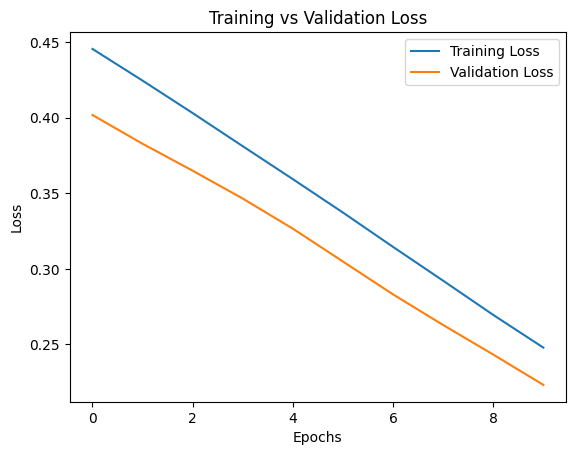

In [ ]:
# Plot Training and Validation Loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Making the Predictions on Test Data
# Predicting the test data
predictions = model.predict(X_test)

print("First 5 Predictions:")
print(predictions[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
First 5 Predictions:
[[0.18960546]
 [0.23831545]
 [0.25477123]
 [0.22671737]
 [0.15533735]]


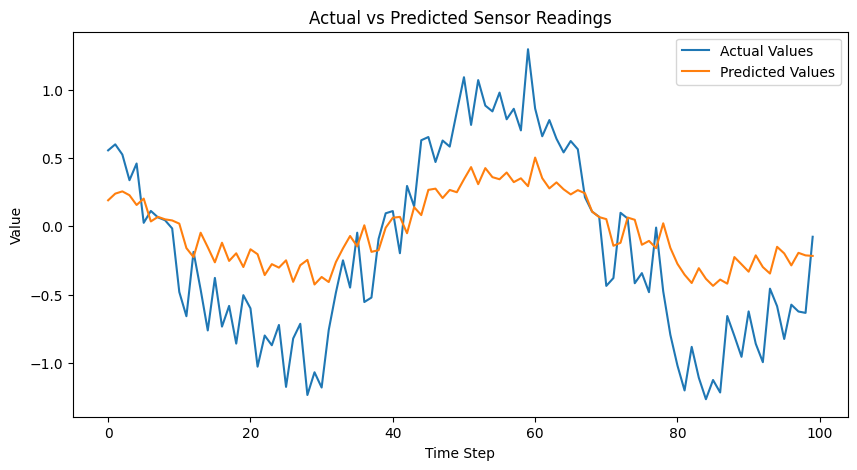

In [ ]:
# Plot Actual vs Predicted Values
plt.figure(figsize=(10,5))

plt.plot(y_test, label='Actual Values')
plt.plot(predictions, label='Predicted Values')

plt.title("Actual vs Predicted Sensor Readings")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()

plt.show()

In [ ]:
# Calculating the RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 0.2232718774019449
Root Mean Squared Error (RMSE): 0.47251653664389875
